In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from utilsforecast.plotting import plot_series
from statsforecast.models import AutoETS
from statsforecast import StatsForecast

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

df=pd.read_csv("data/olympic_running_unparsed.csv")
df.dropna(inplace=True)
data = df.groupby('Year')['Time'].min().reset_index()

# 2. Rename to the "Magic Names" statsforecast requires
data.columns = ['ds', 'y']

# 3. Add the 'unique_id' (Mandatory even for a single series)
data['unique_id'] = '100m_sprint'

# 4. Ensure 'ds' is datetime
data['ds'] = pd.to_datetime(data['ds'], format="%Y")


ran=int(len(data)*0.8)
X=data.iloc[:ran]
y=data.iloc[ran:]


model=StatsForecast(models=[AutoETS(season_length=1, model='AAN')],freq='4AS',)
model.fit(X)
y_pred=model.predict(h=len(y))





c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


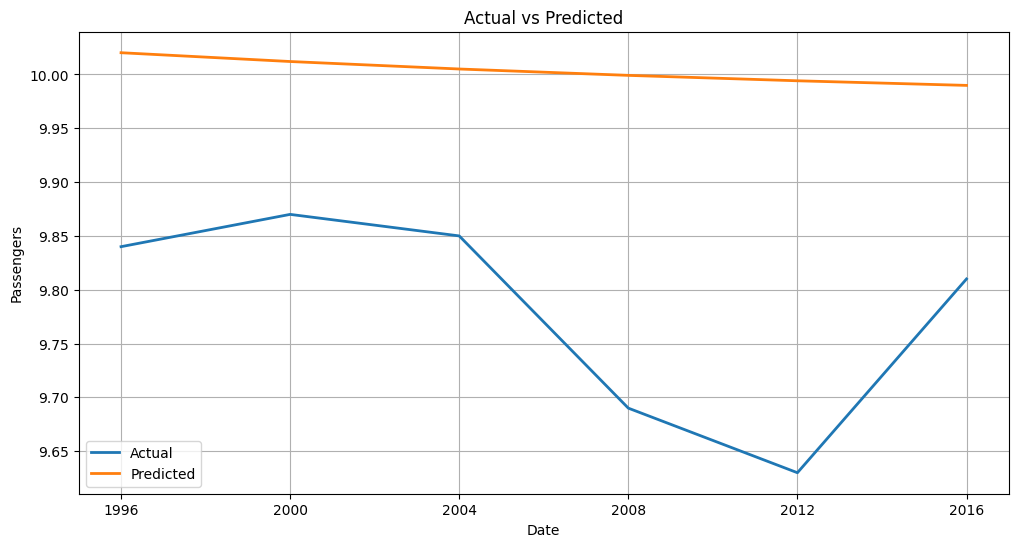

In [3]:
actual = y.copy()

# Predicted values
pred = y_pred.copy()

plt.figure(figsize=(12,6))

# plot actual
plt.plot(actual['ds'], actual['y'], label='Actual', linewidth=2)

# plot predicted
plt.plot(pred['ds'], pred['AutoETS'], label='Predicted', linewidth=2)

plt.xlabel("Date")
plt.ylabel("Passengers")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
pbs=(
    pd.read_csv("data/PBS_unparsed.csv",parse_dates=["Month"])
     [["Month","Concession","Type","ATC1","ATC2","Scripts","Cost"]]
     )
pbs

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


In [5]:
a10=(
    pbs.loc[pbs["ATC2"]=="A10"].drop(columns=['ATC1','ATC2'])    
)
a10

,Month,Concession,Type,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,89733,2092878.0
1525,1991-08-01,Concessional,Co-payments,77101,1795733.0
1526,1991-09-01,Concessional,Co-payments,76255,1777231.0
1527,1991-10-01,Concessional,Co-payments,78681,1848507.0
1528,1991-11-01,Concessional,Co-payments,70554,1686458.0
...,...,...,...,...,...
52339,2008-02-01,General,Safety net,10869,530709.0
52340,2008-03-01,General,Safety net,1119,51773.0
52341,2008-04-01,General,Safety net,721,36289.0
52342,2008-05-01,General,Safety net,1947,101233.0


In [6]:
total_cost_df=(
    pbs.loc[pbs["ATC2"]=="A10"]
    .drop(columns=['ATC1','ATC2'])
    .groupby('Month',as_index=False)
    .agg({'Cost':'sum'})
    .rename(columns={'Cost':"TotalC"}) 
)
total_cost_df

,Month,TotalC
0,1991-07-01,3526591.0
1,1991-08-01,3180891.0
2,1991-09-01,3252221.0
3,1991-10-01,3611003.0
4,1991-11-01,3565869.0
...,...,...
199,2008-02-01,21654285.0
200,2008-03-01,18264945.0
201,2008-04-01,23107677.0
202,2008-05-01,22912510.0


In [7]:
total_cost_df=(
    pbs.loc[pbs["ATC2"]=="A10"]
    .drop(columns=['ATC1','ATC2'])
    .groupby('Month',as_index=False)
    .agg({'Cost':'sum'})
    .assign(Cost=lambda x:(x['Cost']/1e6).round(2)) 
)
total_cost_df

,Month,Cost
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


In [8]:
prison=(pd.read_csv("data/prison_population.csv",parse_dates=["Date"])
                   .rename(columns={"Date":"Quarter"})
                   .sort_values(by=["State","Gender","Legal","Indigenous"])
                   )
prison


,Quarter,State,Gender,Legal,Indigenous,Count
0,2005-03-01,ACT,Female,Remanded,ATSI,0
64,2005-06-01,ACT,Female,Remanded,ATSI,1
128,2005-09-01,ACT,Female,Remanded,ATSI,0
192,2005-12-01,ACT,Female,Remanded,ATSI,0
256,2006-03-01,ACT,Female,Remanded,ATSI,1
...,...,...,...,...,...,...
2815,2015-12-01,WA,Male,Sentenced,Non-ATSI,2503
2879,2016-03-01,WA,Male,Sentenced,Non-ATSI,2488
2943,2016-06-01,WA,Male,Sentenced,Non-ATSI,2539
3007,2016-09-01,WA,Male,Sentenced,Non-ATSI,2608


AttributeError: 'numpy.ndarray' object has no attribute 'legend'

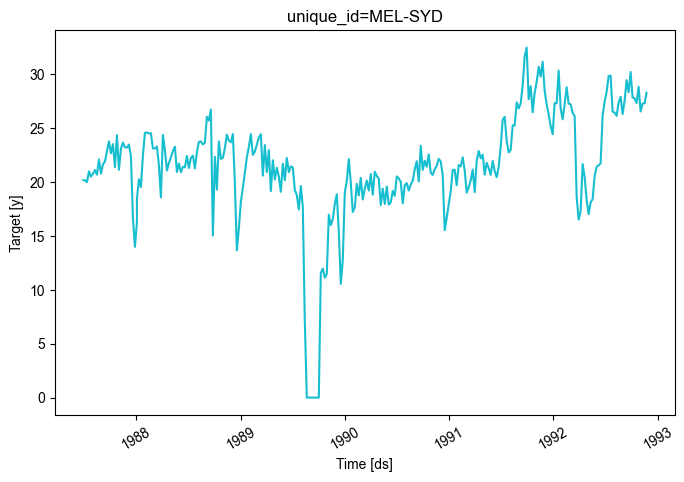

In [9]:
from utilsforecast.plotting import plot_series
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

fig, ax = plt.subplots(figsize=(8, 5))
sns.set_style("whitegrid")
melsyd_economy=(
    pd.read_csv("data/ansett.csv",parse_dates=["ds"])
                .loc[lambda x:(x['Airports']=='MEL-SYD')&(x['Class']=='Economy')]
                .rename(columns={"Airports":"unique_id"})
                .assign(y=lambda x:x["y"]/1000)
                )
plot_series( df=melsyd_economy, id_col="unique_id", time_col="ds", target_col="y",ax=ax,engine="plotly")
ax.set_xlabel("Week [1W]")
ax.set_ylabel("Passengers ('000)")
ax.set_title("Ansett airlines economy class: Melbourne-Sydney")

px.show()

AttributeError: 'numpy.ndarray' object has no attribute 'legend'

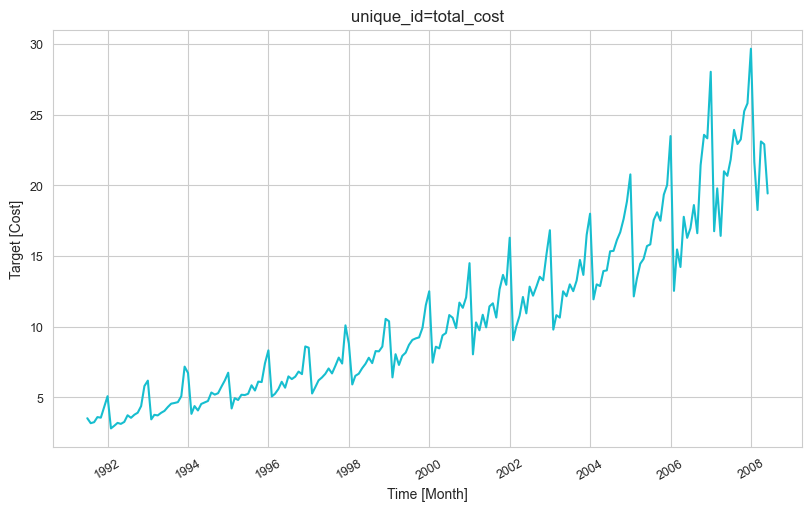

In [ ]:
import matplotlib.pyplot as plt

# Then run your plot_series code again without the backend change

fig, ax = plt.subplots(figsize=(8, 5))
plot=plot_series(total_cost_df.assign(unique_id="total_cost"),time_col="Month",target_col="Cost",ax=ax,engine="plotly")
ax.set_xlabel("Month [1M]")
ax.set_ylabel("$ (millions)")
ax.set_title("Australian antidiabetic drug sales")
plot.show()


In [ ]:
import pandas as pd
from utilsforecast.plotting import plot_series
import plotly.io as pio



df = pd.read_csv("data/ansett.csv", parse_dates=["ds"])
melsyd_economy = (
    df.loc[lambda x: (x['Airports'].str.strip() == 'MEL-SYD') & 
    (x['Class'].str.strip() == 'Economy')]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
    )

melsyd_economy.head()



   

,ds,unique_id,Class,y
3881,1987-06-29,MEL-SYD,Economy,20.167
3882,1987-07-06,MEL-SYD,Economy,20.161
3883,1987-07-13,MEL-SYD,Economy,19.993
3884,1987-07-20,MEL-SYD,Economy,20.986
3885,1987-07-27,MEL-SYD,Economy,20.497


AttributeError: 'numpy.ndarray' object has no attribute 'legend'

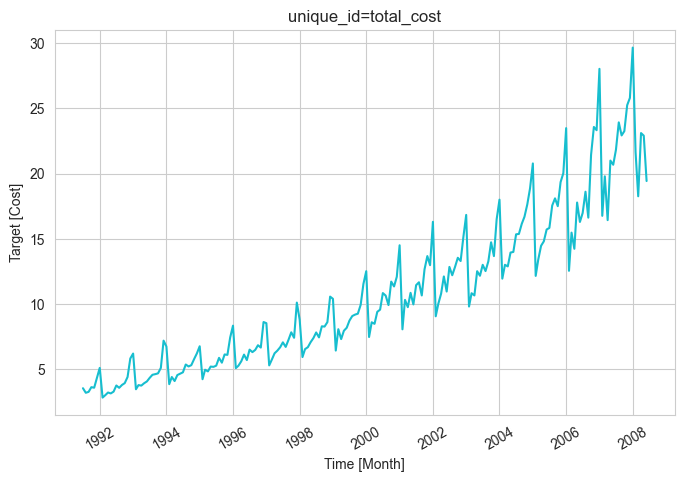

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_series(total_cost_df.assign(unique_id="total_cost"),time_col='Month',target_col='Cost',ax=ax,engine='plotly')
ax.set_xlabel("Week [1W]")
ax.set_ylabel("Passengers ('000)")
ax.set_title("Ansett Airlines economy class : Melbourne-Sydney")



px.show()


C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_40028\530941030.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


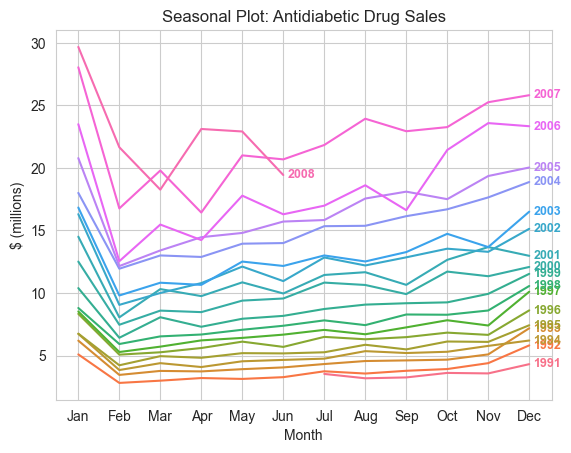

In [ ]:
#Seasnoal plots
df=total_cost_df.assign(Month_name=total_cost_df['Month'].dt.strftime("%b"),
                        Year=total_cost_df['Month'].dt.year,
                        Month_num=total_cost_df['Month'].dt.month,
                        )
unique_years=df["Year"].unique()
year_pal=sns.color_palette("husl",n_colors=len(unique_years))

fig,ax=plt.subplots()
sns.lineplot(data=df,x='Month_num',y="Cost",hue="Year",palette=year_pal,legend=False,ax=ax)

ax.set(title="Seasonal Plot: Antidiabetic Drug Sales",xlabel="Month",ylabel="$ (millions)",xticks=range(1,13),xticklabels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

min_year=unique_years.min()
for year,subset in df.groupby("Year"):
    x=subset['Month_num'].iloc[-1]+0.1
    y=subset['Cost'].iloc[-1]
    color=year_pal[year-min_year]
    ax.text(x,y,str(year),ha="left",va="center",fontsize=9,weight="bold",color=color)
fig.show()

C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_25008\2431518530.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


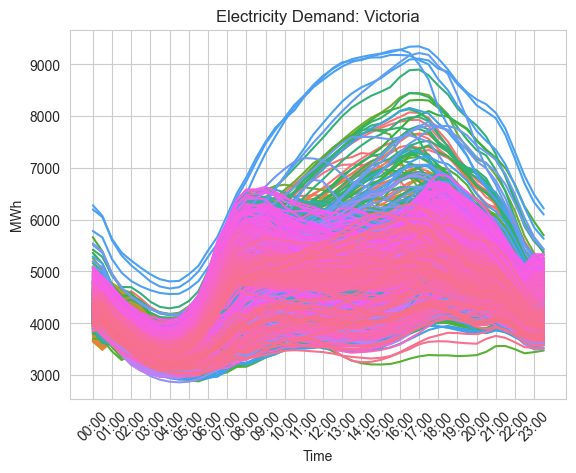

In [ ]:
#multiple Seasonal Periods

df=pd.read_csv("data/vic_elec.csv",parse_dates=['ds'])
df=df[df['unique_id']=="Demand"]

df=df.assign(hour_minute=lambda x:x['ds'].dt.strftime("%H:%M"),
             day=lambda x:x["ds"].dt.date,
             )

fig,ax=plt.subplots()

sns.lineplot(data=df,x="hour_minute",y="y",
             hue="day",palette="husl",
             legend=False,ax=ax)

ax.set(title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",)

unique_ticks=df['hour_minute'].unique()
ticks=range(0,len(unique_ticks),2)
ticklabels=unique_ticks[::2]
ax.set_xticks(ticks, labels=ticklabels, rotation=45)
fig.show()

C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_25008\2302257252.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


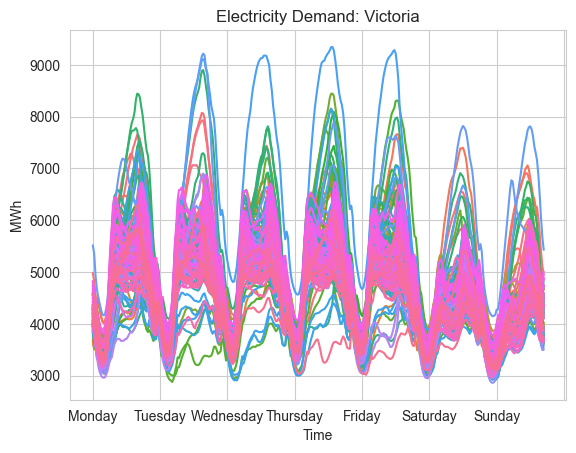

In [ ]:
df=(df.loc[lambda x:x['ds'].between("2012-01-02","2014-12-28 23:59")]
    .assign(day_of_week=lambda x:x["ds"].dt.day_name(),
            week=lambda x:x['ds'].dt.to_period("W").dt.start_time,
        )
    )
unique_weeks=df["week"].unique()
palette=sns.color_palette('husl',n_colors=len(unique_weeks))
color_map=dict(zip(unique_weeks,palette))

fig,ax=plt.subplots()
for week,df_week in df.groupby("week"):
    df_week.plot(x="day_of_week",y="y",ax=ax,color=color_map[week])
ax.get_legend().remove()
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
fig.show()
    


C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_25008\2841441414.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


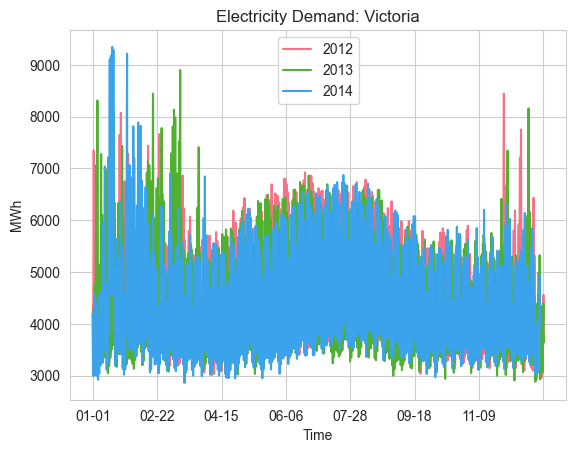

In [ ]:
df=df.assign(
    day_of_year=lambda x:x['ds'].dt.strftime("%m-%d"),
    year=lambda x:x['ds'].dt.year,
        )
palette = sns.color_palette("husl", n_colors=df["year"].nunique())
fig,ax=plt.subplots()
for i_year,(year,df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="day_of_year",y="y",ax=ax,label=str(year),color=palette[i_year])
ax.set(
    title="Electricity Demand: Victoria",
    ylabel="MWh",
    xlabel="Time",
)
fig.show()


C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_25008\268263071.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


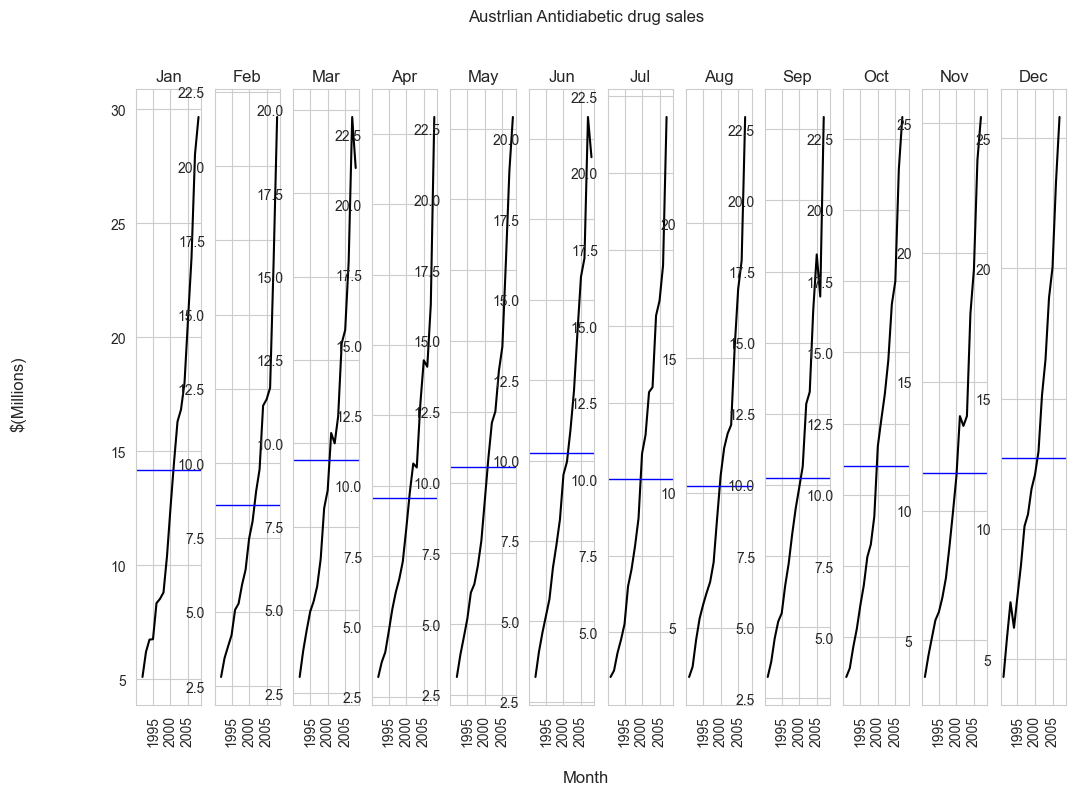

In [ ]:
#focusing on the Subseason plots!!

df=total_cost_df.assign(
    year=total_cost_df["Month"].dt.year,
    month_name=total_cost_df['Month'].dt.month_name(),
    month_idx=total_cost_df['Month'].dt.month,
)
fig,axes=plt.subplots(1,12,figsize=(12,8),sharex=True)


for ax,((_,month_name),month_df) in zip(axes,df.groupby(['month_idx','month_name'])):
    mean_cost=month_df['Cost'].mean()
    ax.plot(month_df['year'],month_df['Cost'],color='k')
    ax.axhline(mean_cost,color='b',linewidth=1)
    ax.set(title=month_name[:3],xlabel="")
    ax.tick_params(axis="x",rotation=90)
fig.suptitle("Austrlian Antidiabetic drug sales")
fig.supxlabel("Month")
fig.supylabel("$(Millions)")
fig.show()

In [10]:
tourism=pd.read_csv("data/tourism.csv",parse_dates=['ds'])
trips=(
    tourism.loc[lambda x:x['Purpose']=="Holiday"]
    .groupby(['State','ds'],as_index=False).agg({"y":"sum"})
    
)
trips

,State,ds,y
0,ACT,1998-01-01,196.218550
1,ACT,1998-04-01,126.770597
2,ACT,1998-07-01,110.679645
3,ACT,1998-10-01,170.472206
4,ACT,1999-01-01,107.779245
...,...,...,...
635,Western Australia,2016-10-01,982.752589
636,Western Australia,2017-01-01,1134.352019
637,Western Australia,2017-04-01,997.852225
638,Western Australia,2017-07-01,879.988533


C:\Users\AFROCHEM\AppData\Local\Temp\ipykernel_30664\2265244400.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


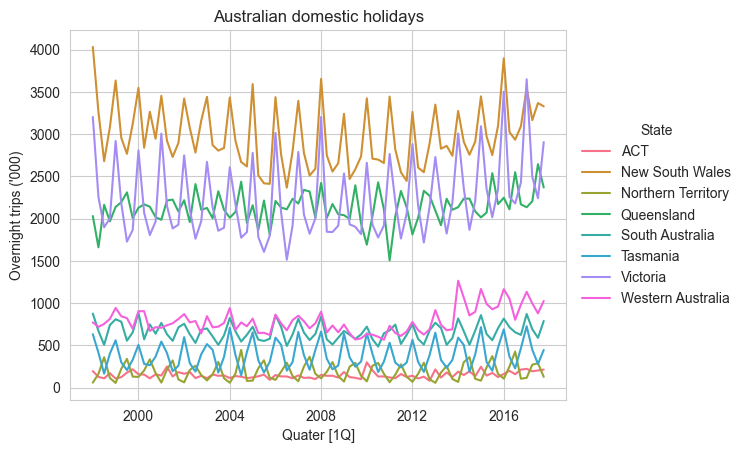

In [13]:
fig,ax=plt.subplots()
palette=sns.color_palette("husl",trips['State'].nunique())
sns.lineplot(data=trips,x="ds",y="y",hue="State",palette=palette)
ax.set(
    title="Australian domestic holidays",
    ylabel="Overnight trips ('000)",
    xlabel="Quater [1Q]",
)
ax.legend(loc="center left",bbox_to_anchor=(1.02,0.5),frameon=False,borderaxespad=0,title="State")
fig.show()

In [ ]:
df=trips.assign(Quarter="Q"+trips["ds"].dt.quarter.astype("string"),
                Year=trips["ds"].dt.year,)
num_states,num_years=df[["State","Year"]].nunique()
palette = sns.color_palette("husl", num_years)
fig,axes=plt.subplots(num_states,sharex=True,figsize=(8,10))
for ax,(state,state_df) in zip(axes,df.groupby("State")):
    sns.lineplot(data=state_df,x="Quater",y="y",hue="Year",palatte=palette,ax=ax)
    ax.get_legend().remove()
    ax.set(ylabel="")
    ax.text(1.02,0.5,state,va="center",ha="right",rotate=270,size="medium",transform=ax.transAxes)
    handles,labels=ax.get_legend_handles_labels()
    for h in handles:
        h.set(linewidth=4)
    fig.legend(handles,labels,title="Year",loc="center left",bbox_to_anchor=(1.05,0.5),frameon=False,borderaxespad=0)
    fig.suptitle("Australian domestic hoildays")
    fig.supylabel("Overnight trips ('000)")
    fig.show()

(8, 20)